In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from sklearn.metrics import (
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
books = pd.read_csv('Books.csv',encoding='latin-1')

ratings = pd.read_csv('Ratings.csv', encoding='latin-1')

users = pd.read_csv('Users.csv',encoding='latin-1')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)

Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


In [4]:
print("Books:")
display(books.head())

print("\nRatings:")
display(ratings.head())

print("\nUsers:")
display(users.head())

Books:


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...



Ratings:


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



Users:


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
print("Books columns:")
print(books.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nUsers columns:")
print(users.columns.tolist())

Books columns:
['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']

Ratings columns:
['User-ID', 'ISBN', 'Book-Rating']

Users columns:
['User-ID', 'Location', 'Age']


In [6]:
print("Missing values in Books:")
display(books.isnull().sum())

print("\nMissing values in Ratings:")
display(ratings.isnull().sum())

print("\nMissing values in Users:")
display(users.isnull().sum())

Missing values in Books:


ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


Missing values in Ratings:


User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


Missing values in Users:


User-ID          0
Location         0
Age         110762
dtype: int64

In [7]:
print(
    ratings['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


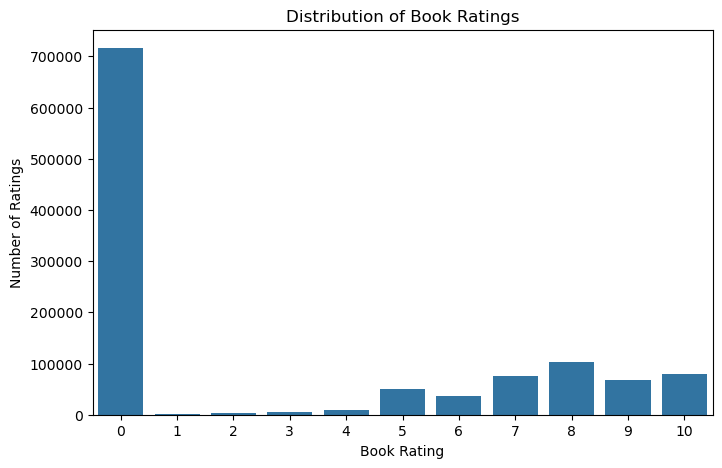

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='Book-Rating',
    data=ratings
)

plt.title('Distribution of Book Ratings')
plt.xlabel('Book Rating')
plt.ylabel('Number of Ratings')

plt.show()

In [9]:
ratings_explicit = ratings[
    ratings['Book-Rating'] > 0
].copy()

print("Original ratings:", ratings.shape)
print("Explicit ratings:", ratings_explicit.shape)

Original ratings: (1149780, 3)
Explicit ratings: (433671, 3)


In [10]:
print(
    ratings_explicit['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


In [11]:
books_cb = books[
    [
        'ISBN',
        'Book-Title',
        'Book-Author',
        'Year-Of-Publication',
        'Publisher'
    ]
].copy()

In [12]:
books_cb['Book-Title'] = (
    books_cb['Book-Title']
    .fillna('')
    .astype(str)
)

books_cb['Book-Author'] = (
    books_cb['Book-Author']
    .fillna('')
    .astype(str)
)

books_cb['Publisher'] = (
    books_cb['Publisher']
    .fillna('')
    .astype(str)
)

In [13]:
books_cb['content'] = (
    books_cb['Book-Title'] + ' ' +
    books_cb['Book-Author'] + ' ' +
    books_cb['Publisher']
)

display(
    books_cb[
        [
            'Book-Title',
            'Book-Author',
            'Publisher',
            'content'
        ]
    ].head()
)

,Book-Title,Book-Author,Publisher,content
0,Classical Mythology,Mark P. O. Morford,Oxford University Press,Classical Mythology Mark P. O. Morford Oxford ...
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,Clara Callan Richard Bruce Wright HarperFlamin...
2,Decision in Normandy,Carlo D'Este,HarperPerennial,Decision in Normandy Carlo D'Este HarperPerennial
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,Flu: The Story of the Great Influenza Pandemic...
4,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,The Mummies of Urumchi E. J. W. Barber W. W. N...


In [14]:
books_cb = books_cb.drop_duplicates(
    subset=['Book-Title']
).reset_index(drop=True)

print("Books after removing duplicates:", books_cb.shape)

Books after removing duplicates: (242135, 6)


In [15]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=30000
)

tfidf_matrix = tfidf.fit_transform(
    books_cb['content']
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (242135, 30000)


In [16]:
book_indices = pd.Series(
    books_cb.index,
    index=books_cb['Book-Title']
)

book_indices = book_indices[
    ~book_indices.index.duplicated(keep='first')
]

print("Book index created.")

Book index created.


In [17]:
def content_based_recommendations(
    book_title,
    num_recommendations=10
):
    
    # Check whether book exists
    if book_title not in book_indices:
        return pd.DataFrame({
            'Message': [
                'Book not found in dataset.'
            ]
        })
    
    # Get index
    idx = book_indices[book_title]
    
    # Calculate cosine similarity
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()
    
    # Get most similar books
    similar_indices = similarity_scores.argsort()[
        -num_recommendations-1:
    ][::-1]
    
    # Remove the original book
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ][:num_recommendations]
    
    # Create result
    recommendations = books_cb.iloc[
        similar_indices
    ][
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ].copy()
    
    recommendations[
        'Similarity Score'
    ] = similarity_scores[similar_indices]
    
    return recommendations

In [18]:
books_cb['Book-Title'].head(20).tolist()

['Classical Mythology',
 'Clara Callan',
 'Decision in Normandy',
 'Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It',
 'The Mummies of Urumchi',
 "The Kitchen God's Wife",
 "What If?: The World's Foremost Military Historians Imagine What Might Have Been",
 'PLEADING GUILTY',
 'Under the Black Flag: The Romance and the Reality of Life Among the Pirates',
 "Where You'll Find Me: And Other Stories",
 'Nights Below Station Street',
 "Hitler's Secret Bankers: The Myth of Swiss Neutrality During the Holocaust",
 'The Middle Stories',
 'Jane Doe',
 "A Second Chicken Soup for the Woman's Soul (Chicken Soup for the Soul Series)",
 'The Witchfinder (Amos Walker Mystery Series)',
 'More Cunning Than Man: A Social History of Rats and Man',
 'Goodbye to the Buttermilk Sky',
 'The Testament',
 'Beloved (Plume Contemporary Fiction)']

In [19]:
test_book = books_cb['Book-Title'].iloc[0]

print("Test book:", test_book)

Test book: Classical Mythology


In [20]:
content_recommendations = (
    content_based_recommendations(
        test_book,
        10
    )
)

display(content_recommendations)

,ISBN,Book-Title,Book-Author,Publisher,Similarity Score
184687,0195210301,Who's Who in Classical Mythology (Who's Who Se...,Michael Grant,Oxford University Press,0.760706
101622,0582280044,Classical mythology,Mark P.O Morford,Longman,0.737439
170182,0198721129,The Oxford History of the Classical World,Oswyn Murray,Oxford University Press,0.584279
97698,0192177478,A Dictionary of World Mythology (Oxford Paperb...,Arthur Cottrell,Oxford University Press,0.544182
50072,019866172X,The Oxford Classical Dictionary,Simon Hornblower,Oxford University Press,0.541184
97417,0192752235,The Ennead,Jan Mark,Oxford University Press,0.536481
97225,0192814907,The Oxford Companion to Classical Literature (...,Paul H. Harvey,Oxford University Press,0.524757
40181,0844255610,Mythology and You : Classical Mythology and it...,Donna Rosenberg,Glencoe/McGraw-Hill,0.515674
183143,0195123034,The Classical Greek Reader,Kenneth J. Atchity,Oxford University Press,0.513790
170186,0198601654,The Oxford Companion to Classical Civilization,Simon Hornblower,Oxford University Press,0.496366


In [21]:
possible_books = [
    'The Hobbit',
    'Harry Potter and the Sorcerer\'s Stone',
    'The Da Vinci Code',
    'The Catcher in the Rye'
]

for book in possible_books:
    if book in book_indices:
        print("Found:", book)

Found: The Hobbit
Found: Harry Potter and the Sorcerer's Stone
Found: The Da Vinci Code
Found: The Catcher in the Rye


In [22]:
content_based_recommendations(
    'The Hobbit',
    10
)

,ISBN,Book-Title,Book-Author,Publisher,Similarity Score
13357,8845906884,Lo Hobbit / The Hobbit,J. R. R. Tolkien,Distribooks,0.762767
155787,1560600543,Hobbit,J. R. R. Tolkien,Eclipse Books,0.740668
112275,0618134700,"The Annotated Hobbit: The Hobbit, Or, There an...",J.R.R. Tolkien,Houghton Mifflin Company,0.733572
2711,0618002219,The Hobbit: or There and Back Again,J.R.R. Tolkien,Houghton Mifflin Company,0.718442
66122,0395520215,"The Hobbit: Or, There and Back Again",J. R. R. Tolkien,Houghton Mifflin Company,0.718442
14814,0618260307,The Hobbit: Or There and Back Again,J. R. R. Tolkien,Houghton Mifflin Company,0.718442
33033,0618009345,Poems from The Hobbit,J. R. R. Tolkien,Houghton Mifflin,0.690494
25682,8445071416,El Hobbit,J. R. R. Tolkien,Minotauro,0.680694
28014,0395873460,The Hobbit (Illustrated Edition),J. R. R. Tolkien,Houghton Mifflin Co,0.653041
14787,2253049417,"Bilbo, Le Hobbit",J. R. R. Tolkien,Pocket (FR),0.650504


In [29]:
ratings_explicit = ratings[
    ratings['Book-Rating'] >0
    ].copy()

In [30]:
RELEVANT_THRESHOLD = 7

In [31]:
user_rating_counts = (
    ratings_explicit
    .groupby('User-ID')
    .size()
)

test_users = user_rating_counts[
    user_rating_counts >= 10
].index

print("Number of test users:", len(test_users))

Number of test users: 7334


In [32]:
def content_based_recommendations(
    book_title,
    num_recommendations=10
):
    
    if book_title not in book_indices:
        return pd.DataFrame()
    
    idx = book_indices[book_title]
    
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()
    
    similar_indices = similarity_scores.argsort()[
        -num_recommendations-1:
    ][::-1]
    
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ][:num_recommendations]
    
    recommendations = books_cb.iloc[
        similar_indices
    ][
        ['ISBN', 'Book-Title', 'Book-Author']
    ].copy()
    
    recommendations['Similarity'] = (
        similarity_scores[similar_indices]
    )
    
    return recommendations

In [33]:
test_book = books_cb['Book-Title'].iloc[0]

print("Input book:")
print(test_book)

print("\nRecommended books:")

display(
    content_based_recommendations(
        test_book,
        10
    )
)

Input book:
Classical Mythology

Recommended books:


,ISBN,Book-Title,Book-Author,Similarity
184687,0195210301,Who's Who in Classical Mythology (Who's Who Se...,Michael Grant,0.760706
101622,0582280044,Classical mythology,Mark P.O Morford,0.737439
170182,0198721129,The Oxford History of the Classical World,Oswyn Murray,0.584279
97698,0192177478,A Dictionary of World Mythology (Oxford Paperb...,Arthur Cottrell,0.544182
50072,019866172X,The Oxford Classical Dictionary,Simon Hornblower,0.541184
97417,0192752235,The Ennead,Jan Mark,0.536481
97225,0192814907,The Oxford Companion to Classical Literature (...,Paul H. Harvey,0.524757
40181,0844255610,Mythology and You : Classical Mythology and it...,Donna Rosenberg,0.515674
183143,0195123034,The Classical Greek Reader,Kenneth J. Atchity,0.513790
170186,0198601654,The Oxford Companion to Classical Civilization,Simon Hornblower,0.496366


In [34]:
test_user = test_users[0]

print("Test User:", test_user)

Test User: 183


In [35]:
user_ratings = ratings_explicit[
    ratings_explicit['User-ID'] == test_user
]

liked_books = user_ratings[
    user_ratings['Book-Rating'] >= RELEVANT_THRESHOLD
]

print(
    "Number of liked books:",
    len(liked_books)
)

display(liked_books.head())

Number of liked books: 83


,User-ID,ISBN,Book-Rating
9745,183,100940/86,9
9749,183,127420/98,8
9750,183,13440/86,7
9752,183,1351394403,8
9753,183,140274871,8


In [36]:
liked_books_with_titles = liked_books.merge(
    books[
        ['ISBN', 'Book-Title']
    ],
    on='ISBN',
    how='inner'
)

display(
    liked_books_with_titles.head()
)

,User-ID,ISBN,Book-Rating,Book-Title
0,183,2070567842,8,Folio Junior: L'histoire De Monsieur Sommer
1,183,8401422825,9,Fahrenheit 451
2,183,8440630794,7,Cuentos del Planeta Tierra
3,183,847223973X,9,Que Se Mueran Los Feos (Fabula)
4,183,8476409419,8,Estudios sobre el amor


In [37]:
input_book = (
    liked_books_with_titles[
        'Book-Title'
    ].iloc[0]
)

print("Input book:", input_book)

Input book: Folio Junior: L'histoire De Monsieur Sommer


In [38]:
recommendations = (
    content_based_recommendations(
        input_book,
        10
    )
)

display(recommendations)

,ISBN,Book-Title,Book-Author,Similarity
165708,2070566153,L'Histoire de monsieur Sommer,Patrick Suskind,0.528594
7874,2070360024,"L'Etranger (Collection Folio, 2)",Albert Camus,0.374204
108932,2070513416,Le petit Nicolas a des ennuis,Goscinny Sempe,0.365798
103035,2070403076,Truismes,Marie Darrieusecq,0.340087
139014,2070513343,Vacances Du Petit Nicolas,Goscinny Sempe,0.339692
216115,2070334759,Petit Nicolas Et Les Copains (Folio - Junior S...,Jean-Jacques Sempe,0.310624
83875,2070392600,Petit Nicolas Et Les Copains,Jean-Jacques Sempe,0.301220
9677,2070332748,Histoires du gaillard d'avant (Collection Foli...,Jean Ollivier,0.299368
41851,2070425827,Jeunesse,Joseph Conrad,0.294668
75015,2070323021,L'Homme Revolte (Folio Essais Series : No 15),Albert Camus,0.288844


In [39]:
actual_relevant_books = set(
    liked_books['ISBN']
)

recommended_books = set(
    recommendations['ISBN']
)

print(
    "Relevant books:",
    actual_relevant_books
)

print(
    "Recommended books:",
    recommended_books
)

Relevant books: {'9726081378', '2070567842', '9722330950', '9728440804', '100940/86', '9722105507', '9724508552', '9728440006', '9726081424', '9722020242', '9726593855', '9724128725', '9728440200', '9724502023', '9728440405', '9721033561', '9722319914', '9728313039', '18128/87', '9728440693', '16560/87', '9728440170', '8401422825', '8497890663', '15019/87', '9728487142', '9728440057', '9722113747', '127420/98', '9728440138', '9728440383', '9748440537', '9728305729', '30623/89', '9727110541', '9726101034', '40052/90', '203671/03', '9724114384', '75666/95', '9726080630', '9728440324', '8440630794', '9726653525', '9729852405', '9724509524', '9727100112', '40614/2098', '8585362693', '972975831X', '9728487150', '18678/87', '9714511081', '9721035130', '8585443464', '97245146089', '9726993474', '8476409419', '13440/86', '9724131009', '9721028800', '9728487002', '140274871', '9726081327', '77556/94', '9728440642', '80651/94', '9728515227', '9728440030', '36388/90', '1351394403', '9728487355', 

In [40]:
relevant_recommended = (
    actual_relevant_books &
    recommended_books
)

print(
    "Relevant recommended books:",
    relevant_recommended
)

print(
    "Number:",
    len(relevant_recommended)
)

Relevant recommended books: set()
Number: 0


In [41]:
k = 10

precision_at_10 = (
    len(relevant_recommended) / k
)

print(
    f"Precision@10: {precision_at_10:.4f}"
)

Precision@10: 0.0000


In [42]:
recall_at_10 = (
    len(relevant_recommended)
    /
    len(actual_relevant_books)
)

print(
    f"Recall@10: {recall_at_10:.4f}"
)

Recall@10: 0.0000


In [43]:
if (
    precision_at_10 + recall_at_10
) > 0:
    
    f1_at_10 = (
        2 *
        precision_at_10 *
        recall_at_10
        /
        (
            precision_at_10 +
            recall_at_10
        )
    )
else:
    f1_at_10 = 0

print(
    f"F1@10: {f1_at_10:.4f}"
)

F1@10: 0.0000


In [44]:
def evaluate_content_based(
    ratings,
    books_cb,
    book_indices,
    num_users=100,
    k=10,
    threshold=7
):
    
    precision_scores = []
    recall_scores = []
    f1_scores = []
    
    # Users with enough ratings
    user_counts = (
        ratings
        .groupby('User-ID')
        .size()
    )
    
    eligible_users = user_counts[
        user_counts >= 10
    ].index
    
    # Select users
    selected_users = (
        eligible_users[:num_users]
    )
    
    for user_id in selected_users:
        
        # User ratings
        user_ratings = ratings[
            ratings['User-ID'] == user_id
        ]
        
        # Books user likes
        liked = user_ratings[
            user_ratings['Book-Rating'] >= threshold
        ]
        
        if len(liked) < 2:
            continue
        
        # Convert ISBN to titles
        liked_with_titles = liked.merge(
            books_cb[
                ['ISBN', 'Book-Title']
            ],
            on='ISBN',
            how='inner'
        )
        
        if len(liked_with_titles) < 2:
            continue
        
        # Select one liked book as input
        input_book = (
            liked_with_titles[
                'Book-Title'
            ].iloc[0]
        )
        
        # Recommend books
        recommendations = (
            content_based_recommendations(
                input_book,
                k
            )
        )
        
        if recommendations.empty:
            continue
        
        recommended_isbn = set(
            recommendations['ISBN']
        )
        
        # Ground truth
        actual_relevant = set(
            liked['ISBN']
        )
        
        # Remove input book from ground truth
        input_isbn = liked_with_titles[
            liked_with_titles['Book-Title']
            == input_book
        ]['ISBN'].iloc[0]
        
        actual_relevant.discard(
            input_isbn
        )
        
        # Intersection
        relevant_recommended = (
            recommended_isbn &
            actual_relevant
        )
        
        # Precision
        precision = (
            len(relevant_recommended)
            /
            k
        )
        
        # Recall
        if len(actual_relevant) > 0:
            recall = (
                len(relevant_recommended)
                /
                len(actual_relevant)
            )
        else:
            recall = 0
        
        # F1
        if precision + recall > 0:
            f1 = (
                2 *
                precision *
                recall
                /
                (precision + recall)
            )
        else:
            f1 = 0
        
        precision_scores.append(
            precision
        )
        
        recall_scores.append(
            recall
        )
        
        f1_scores.append(
            f1
        )
    
    return {
        'Precision@10': np.mean(
            precision_scores
        ),
        'Recall@10': np.mean(
            recall_scores
        ),
        'F1@10': np.mean(
            f1_scores
        ),
        'Users Evaluated': len(
            precision_scores
        )
    }

In [45]:
content_results = evaluate_content_based(
    ratings=ratings_explicit,
    books_cb=books_cb,
    book_indices=book_indices,
    num_users=100,
    k=10,
    threshold=7
)

print(
    "Content-Based Filtering Results"
)

for metric, value in content_results.items():
    print(
        f"{metric}: {value}"
    )

Content-Based Filtering Results
Precision@10: 0.013541666666666667
Recall@10: 0.0071989220789530385
F1@10: 0.009188229959094527
Users Evaluated: 96


In [46]:
content_evaluation = pd.DataFrame({
    'Metric': [
        'Precision@10',
        'Recall@10',
        'F1@10'
    ],
    
    'Score': [
        content_results['Precision@10'],
        content_results['Recall@10'],
        content_results['F1@10']
    ]
})

display(content_evaluation)

,Metric,Score
0,Precision@10,0.013542
1,Recall@10,0.007199
2,F1@10,0.009188


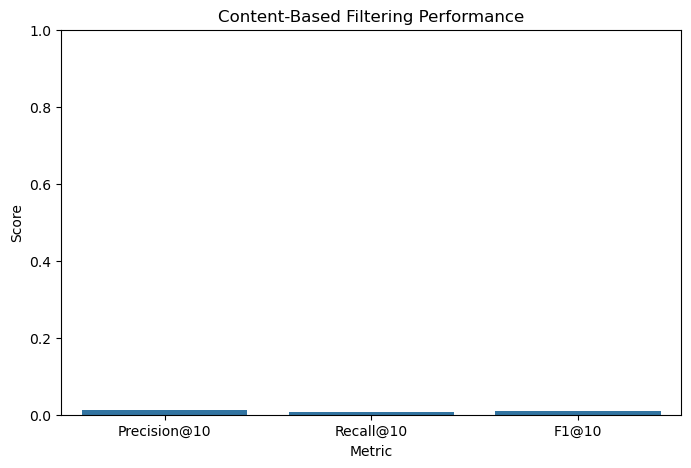

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Metric',
    y='Score',
    data=content_evaluation
)

plt.title(
    'Content-Based Filtering Performance'
)

plt.ylim(0, 1)

plt.show()